In [31]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
df = pd.read_csv('../data/spotify_tracks_clean.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (89740, 24)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,key_label,mode_label
0,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,0.01300,0.000005,0.2660,0.238,131.121,4,dance,2.615717,D,Major
1,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.315617,D,Major
2,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,0.00383,0.000007,0.3710,0.304,128.040,4,pop,2.920633,G,Minor
3,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton,2.710617,G,Minor
4,68305,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,0.09010,0.000027,0.0933,0.425,92.005,4,latino,2.976117,C♯,Minor


In [33]:
FEATURES = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'tempo', 'loudness',
    'speechiness', 'liveness', 'popularity'
]

# higher weight = more influence on recommendations
WEIGHTS = {
    'danceability':     2.0,
    'energy':           2.0,
    'valence':          2.0,
    'acousticness':     1.5,
    'instrumentalness': 1.5,
    'tempo':            1.0,
    'loudness':         1.0,
    'speechiness':      0.5,
    'liveness':         0.5,
    'popularity':       1.0,
}

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

weight_vector  = np.array([WEIGHTS[f] for f in FEATURES])
feature_matrix = df_scaled[FEATURES].values * weight_vector

print(f"Feature matrix : {feature_matrix.shape}")
print(f"Memory         : {feature_matrix.nbytes / 1e6:.1f} MB")

Feature matrix : (89740, 10)
Memory         : 7.2 MB


In [34]:
track_index = pd.Series(df_scaled.index, index=df_scaled['track_id']).to_dict()
print(f"Tracks indexed: {len(track_index):,}")

Tracks indexed: 89,740


In [35]:
def recommend(input_track_ids: list, n: int = 25, top_genres: int = 5) -> pd.DataFrame:
    """
    Given a list of track_ids (user's top 50),
    return n recommendations filtered to the user's top genres.
    """
    known_ids = [t for t in input_track_ids if t in track_index]
    if not known_ids:
        print("No matching track_ids found in dataset.")
        return pd.DataFrame()

    indices = [track_index[t] for t in known_ids]

    # user taste vector = mean of all input track vectors
    taste_vector = feature_matrix[indices].mean(axis=0, keepdims=True)

    # restrict candidates to user's top genres
    user_genres  = (
        df.iloc[indices]['track_genre']
          .value_counts()
          .head(top_genres)
          .index.tolist()
    )
    genre_mask   = df['track_genre'].isin(user_genres)
    cand_indices = df.index[genre_mask].tolist()
    cand_matrix  = feature_matrix[cand_indices]

    scores  = cosine_similarity(taste_vector, cand_matrix)[0]
    results = pd.DataFrame({'cand_idx': cand_indices, 'score': scores})
    results = results[~results['cand_idx'].isin(indices)]
    top_n   = results.sort_values('score', ascending=False).head(n)

    rec_df = df.iloc[top_n['cand_idx'].values][[
        'track_id', 'track_name', 'artists',
        'album_name', 'popularity', 'track_genre'
    ]].copy()
    rec_df['similarity_score'] = top_n['score'].values

    return rec_df.reset_index(drop=True)

In [36]:
# mock: 50 tracks from 3 coherent genres
mock_genres = ['pop', 'hip-hop', 'r-n-b']
mock_pool   = df[df['track_genre'].isin(mock_genres)]
test_input  = mock_pool['track_id'].sample(50, random_state=42).tolist()

print("Input genre distribution:")
print(df[df['track_id'].isin(test_input)]['track_genre'].value_counts())

recs = recommend(test_input, n=25)
print(f"\nRecommendations ({len(recs)} tracks):")
display(recs)

Input genre distribution:
track_genre
r-n-b      20
pop        15
hip-hop    15
Name: count, dtype: int64

Recommendations (25 tracks):


,track_id,track_name,artists,album_name,popularity,track_genre,similarity_score
0,6Q4RJGUzVQym5RL5iq6627,Outro Alguém,Maneva,Mundo Novo,49,r-n-b,0.998584
1,40KUzcToZooV3Gair9v4I9,CHEI DE GATA,Flora Matos,FLORA DE CONTROLE,42,r-n-b,0.997697
2,3aTJREDBpFWYhR5m4i48jO,Inevitavelmente,Maneva,Caleidoscópico,47,r-n-b,0.997547
3,62FCtdHru9nNAJOGbzObi4,"Pode Me Esperar (feat. Meucci, Tasdan & Agatha)",MTK;Meucci;Tasdan;Agatha,"Pode Me Esperar (feat. Meucci, Tasdan & Agatha)",41,r-n-b,0.997487
4,2XK1S04Sdb2XNq4OtH6Xtl,Jogador Número 1,7 Minutoz;Sid;Rod 3030,Jogador Número 1,44,r-n-b,0.997445
5,73N5AghXPjYtAoS6RIYPZd,CHUSAMBA,Emiway Bantai,CHUSAMBA,56,hip-hop,0.997244
6,7xt1AuUbQBZC4yvxxm4nAI,Sohnea,Miss Pooja;Millind Gaba,Sohnea,56,hip-hop,0.996987
7,6GenSQjsQHvJ6ZhwzxJhhL,Castelo Triste,Facção Central,O Espetaculo Do Circo Dos Horrores,42,r-n-b,0.996520
8,3FAuzzj7jM94XjxHmNq8Yr,Mar do Meu Mundo,Maneva,Tempo de Paz,43,r-n-b,0.996189
9,0X7g825ekNNiCWWV7queDr,Mitti De Tibbe,Kaka,Mitti De Tibbe,67,pop,0.996081


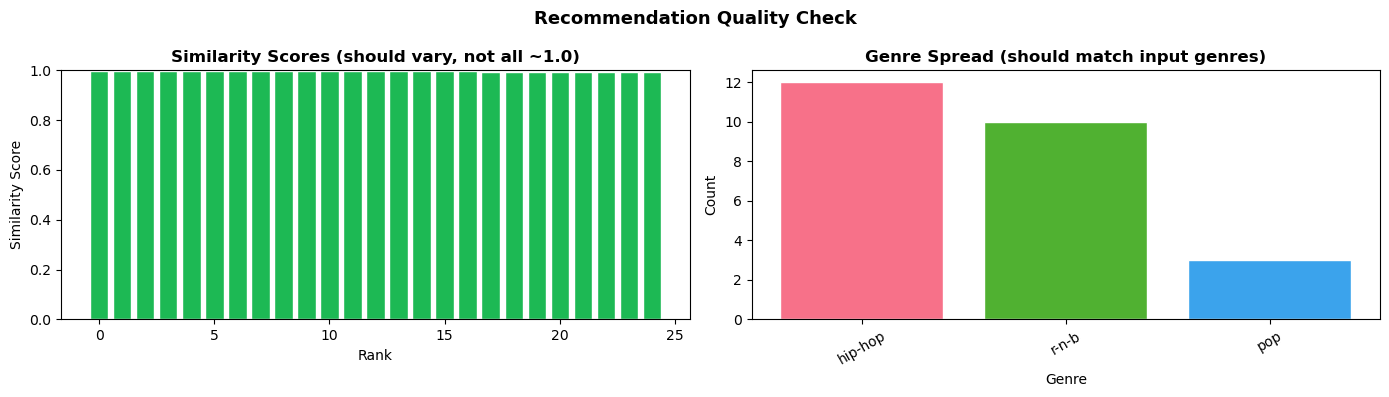


Score range : 0.9938 – 0.9986
Score std   : 0.0013  (higher = better discrimination)


In [37]:
# score distribution — should show spread, not all ~1.0
BG, ACCENT = "#ffffff", '#1DB954'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.labelcolor': "#000000", 'xtick.color': "#000000",
    'ytick.color': "#000000", 'text.color': "#000000",
    'grid.color': "#ffffff", 'axes.titleweight': 'bold'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Recommendation Quality Check', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(len(recs)), recs['similarity_score'], color=ACCENT, edgecolor=BG)
ax.set_title('Similarity Scores (should vary, not all ~1.0)')
ax.set_xlabel('Rank'); ax.set_ylabel('Similarity Score'); ax.set_ylim(0, 1)

ax = axes[1]
genre_counts = recs['track_genre'].value_counts()
ax.bar(genre_counts.index, genre_counts.values,
       color=sns.color_palette('husl', len(genre_counts)), edgecolor=BG)
ax.set_title('Genre Spread (should match input genres)')
ax.set_xlabel('Genre'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

print(f"\nScore range : {recs['similarity_score'].min():.4f} – {recs['similarity_score'].max():.4f}")
print(f"Score std   : {recs['similarity_score'].std():.4f}  (higher = better discrimination)")

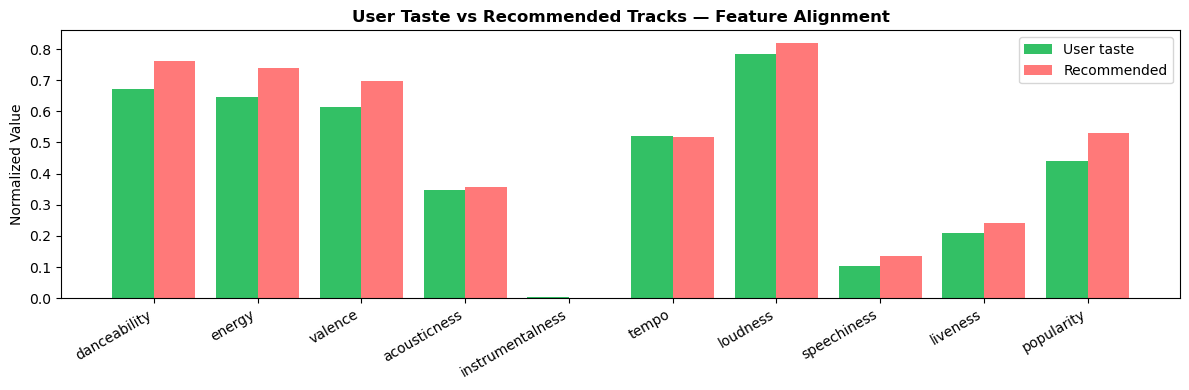

In [38]:
# feature alignment: user taste vs recommended tracks
input_indices = [track_index[t] for t in test_input if t in track_index]
taste_vec     = df_scaled[FEATURES].values[input_indices].mean(axis=0)
rec_indices   = [track_index[t] for t in recs['track_id'] if t in track_index]
rec_vec       = df_scaled[FEATURES].values[rec_indices].mean(axis=0)

x       = np.arange(len(FEATURES))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - 0.2, taste_vec, 0.4, label='User taste',  color=ACCENT,    alpha=0.9)
ax.bar(x + 0.2, rec_vec,   0.4, label='Recommended', color='#ff6b6b', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_ylabel('Normalized Value')
ax.set_title('User Taste vs Recommended Tracks — Feature Alignment')
ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [39]:
artifacts = {
    '../artifacts/feature_matrix.pkl': feature_matrix,
    '../artifacts/track_index.pkl':    track_index,
    '../artifacts/scaler.pkl':         scaler,
    '../artifacts/model_config.pkl':   {'features': FEATURES, 'weights': WEIGHTS},
}

for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved: {path}")

✅ Saved: ../artifacts/feature_matrix.pkl
✅ Saved: ../artifacts/track_index.pkl
✅ Saved: ../artifacts/scaler.pkl
✅ Saved: ../artifacts/model_config.pkl
